In [1]:
%load_ext autoreload
%autoreload 2

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.load_run_data import load_run_data
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from rastermap import Rastermap
import numpy as np
from itertools import combinations
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tqdm import trange
import pickle
from tqdm import tqdm
from sklearn.linear_model import LinearRegression, Lasso, MultiTaskLasso
from sklearn.metrics import r2_score

from analysis.utils import extract_variables

In [6]:
data = load_run_data(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps_logs/initial_conditions',
    add_frames=True,
    n_frames=1)

Found 9 episode directories in /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps_logs/initial_conditions
Loaded 9 episodes
Loaded 9 planning episodes


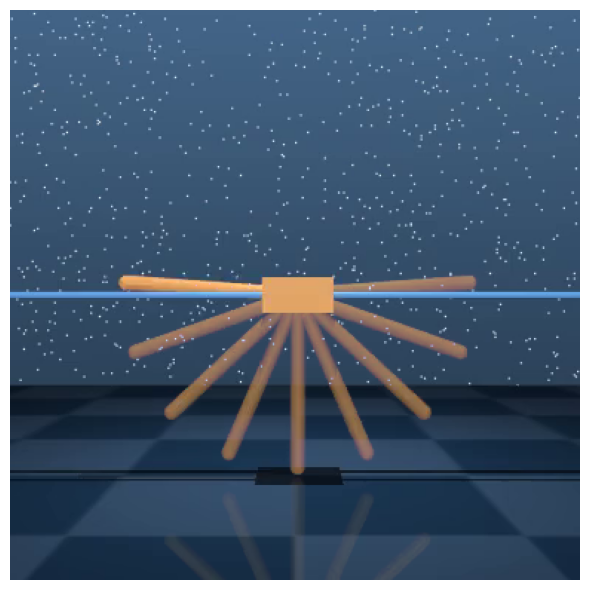

In [26]:
def overlap_frames(frames, pole_alpha=0.3, base_alpha=0.3):
    """
    Overlay multiple frames to show pole trajectory.
    
    Args:
        frames: List of frames to overlay
        pole_alpha: Visibility of the pole overlay (0=invisible, 1=fully visible)
        base_alpha: Visibility of the first frame (0=invisible, 1=fully visible)
    """
    # Filter out None values
    valid_frames = [f for f in frames if f is not None]

    if not valid_frames:
        raise ValueError("No valid frames to overlap")

    # Convert frames to float for processing
    frames_float = [f.astype(float) for f in valid_frames]

    # Use the first frame as the base with reduced visibility
    base_frame = frames_float[0].copy() * base_alpha

    # For subsequent frames, blend them in with reduced opacity
    for frame in frames_float[1:]:
        # Compute the maximum to capture the pole positions
        pole_overlay = np.maximum(base_frame, frame * pole_alpha)
        # Blend: keep more of the base, add pole with reduced alpha
        base_frame = base_frame * (1 - pole_alpha) + pole_overlay * pole_alpha

    # Convert back to uint8
    overlapped = np.clip(base_frame, 0, 255).astype('uint8')

    # Display the overlapped image
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(overlapped)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    return overlapped


overlapped_frame = overlap_frames(data['frames'],
                                  pole_alpha=0.8,
                                  base_alpha=1.0)

In [31]:
exp_vars = extract_variables(
    data,
    variables=['latent_states', 'observations', 'actions', 'rewards'],
    n_steps=500)

In [32]:
for var in exp_vars:
    print(f"{var}: {exp_vars[var][0].shape}")

latent_states: (500, 512)
observations: (500, 5)
actions: (500, 1)
rewards: (500, 1)


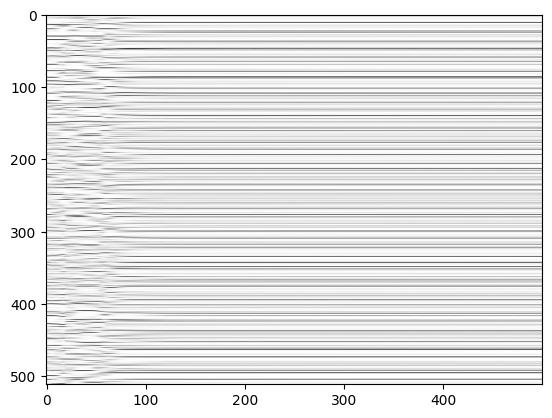

In [33]:
plt.imshow(exp_vars['latent_states'][8].T[:, :500],
           aspect='auto',
           cmap='gray_r')

## Linear decoding


In [92]:
def make_lagged_pairs_for_episode(x_ep, y_ep, lag):
    """Build (X, Y) pairs within one episode for given lag."""
    T = len(x_ep)
    if lag >= 0:
        t_src = np.arange(0, T - lag)
        t_tgt = t_src + lag

    elif lag < 0:
        # Predict the past: (z_t, y_{t+lag}) = (z_t, y_{t-|lag|})
        shift = abs(lag)
        t_src = np.arange(shift, T)
        t_tgt = np.arange(0, T - shift)

    return x_ep[t_src], y_ep[t_tgt]


def bootstrap_ci(vals, alpha=0.05, n_boot=1000):
    rng = np.random.RandomState(0)
    boot_means = np.zeros(n_boot)
    for b in range(n_boot):
        resampled = rng.choice(vals, size=len(vals), replace=True)
        boot_means[b] = np.mean(resampled)

    lower = np.percentile(boot_means, alpha)
    upper = np.percentile(boot_means, 100 - alpha)
    return (lower, upper)

In [126]:
def evaluate_lags_leave_k_out(x_eps,
                              y_eps,
                              lags,
                              k_holdout=1,
                              model='linear_regression',
                              max_combinations=None,
                              add_bootstrap_ci=False,
                              alpha=0.05,
                              n_bootstrap=1000,
                              shuffle_X=False,
                              shuffle_y=False):
    """
    Args:
        x_eps: list of [N_eps_i, L] arrays
        y_eps: list of [N_eps_i, D] arrays   
    """
    n_eps = len(x_eps)
    assert n_eps > k_holdout, "k_holdout must be smaller than number of episodes"

    # Enumerate folds (all combinations or sampled subset)
    all_combos = list(combinations(range(n_eps), k_holdout))
    if max_combinations is not None and len(all_combos) > max_combinations:
        np.random.seed(0)
        all_combos = list(
            np.random.choice(len(all_combos), max_combinations, replace=False))

    if shuffle_X:
        x_eps = [np.random.permutation(x_ep) for x_ep in x_eps]
    if shuffle_y:
        y_eps = [np.random.permutation(y_ep) for y_ep in y_eps]

    r2_by_lag = {lag: [] for lag in lags}
    model_by_lag = {lag: [] for lag in lags}

    for test_idxs in tqdm(all_combos):
        test_idxs = np.atleast_1d(test_idxs)
        train_idxs = [i for i in range(n_eps) if i not in test_idxs]

        for lag in lags:
            # Collect training pairs
            X_train_list, Y_train_list = [], []
            for i in train_idxs:
                X_i, Y_i = make_lagged_pairs_for_episode(
                    x_eps[i], y_eps[i], lag)
                X_train_list.append(X_i)
                Y_train_list.append(Y_i)

            X_train = np.concatenate(X_train_list, axis=0)
            Y_train = np.concatenate(Y_train_list, axis=0)

            if model == 'linear_regression':
                model_to_fit = LinearRegression()
            elif model == 'lasso':
                model_to_fit = Lasso(alpha=0.001)
            elif model == 'multi_task_lasso':
                model_to_fit = MultiTaskLasso(alpha=0.001)
            else:
                raise ValueError(f"Model {model} not supported")

            # Fit model on training set
            model_to_fit = model_to_fit.fit(X_train, Y_train)

            # Evaluate on each held-out episode
            fold_r2s = []
            for j in test_idxs:
                X_te, Y_te = make_lagged_pairs_for_episode(
                    x_eps[j], y_eps[j], lag)
                Y_pred = model_to_fit.predict(X_te)
                r2 = r2_score(Y_te, Y_pred, multioutput='variance_weighted')
                fold_r2s.append(r2)

            r2_by_lag[lag].append(
                np.mean(fold_r2s))  # mean R² over held-out eps in this fold

            model_by_lag[lag].append(model_to_fit)

    # Aggregate mean and std over folds
    r2_mean = {lag: np.mean(vals) for lag, vals in r2_by_lag.items()}
    r2_std = {lag: np.std(vals, ddof=1) for lag, vals in r2_by_lag.items()}

    results = {
        'r2_mean': r2_mean,
        'r2_std': r2_std,
        'r2_by_lag': r2_by_lag,
        'model_by_lag': model_by_lag,
    }

    if add_bootstrap_ci:
        r2_ci = {
            lag: bootstrap_ci(vals, alpha=alpha, n_boot=n_bootstrap)
            for lag, vals in r2_by_lag.items()
        }
        results['r2_ci'] = r2_ci

    return results

In [127]:
combinations_vars = [
    ('latent_states', 'observations'),
    #('latent_states', 'rewards'),
    #('latent_states', 'actions'),
    #('observations', 'observations'),
    #('rewards', 'rewards'),
    #('actions', 'actions'),
]

#models_to_fit = ['linear_regression', 'lasso']
models_to_fit = ['lasso']

results_decoding = {}

for model in models_to_fit:
    for x_var, y_var in combinations_vars:
        print(f"Decoding {x_var} -> {y_var} with {model}")
        results_decoding[f'{x_var}-{y_var}'] = evaluate_lags_leave_k_out(
            exp_vars[x_var],
            exp_vars[y_var],
            model=model,
            lags=np.arange(0, 1),
            k_holdout=1,
            add_bootstrap_ci=True,
            shuffle_X=False,
            shuffle_y=True)

    # # Save results_decoding to pickle file
    # with open(f'results_decoding_{model}.pkl', 'wb') as f:
    #     pickle.dump(results_decoding, f)

Decoding latent_states -> observations with lasso


  0%|          | 0/9 [00:00<?, ?it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.201e+02, tolerance: 2.094e+00
  model = cd_fast.enet_coordinate_descent(
 11%|█         | 1/9 [00:00<00:03,  2.32it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.882e+01, tolerance: 2.117e+00
  model = cd_fast.enet_coordinate_descent(
 22%|██▏       | 2/9 [00:00<00:02,  2.44it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/

In [79]:
# Load the results from pickle file
with open('/home/hgf_hmgu/hgf_gib4562/tdmpc2/results_decoding_lasso.pkl',
          'rb') as f:
    results_decoding_lasso = pickle.load(f)

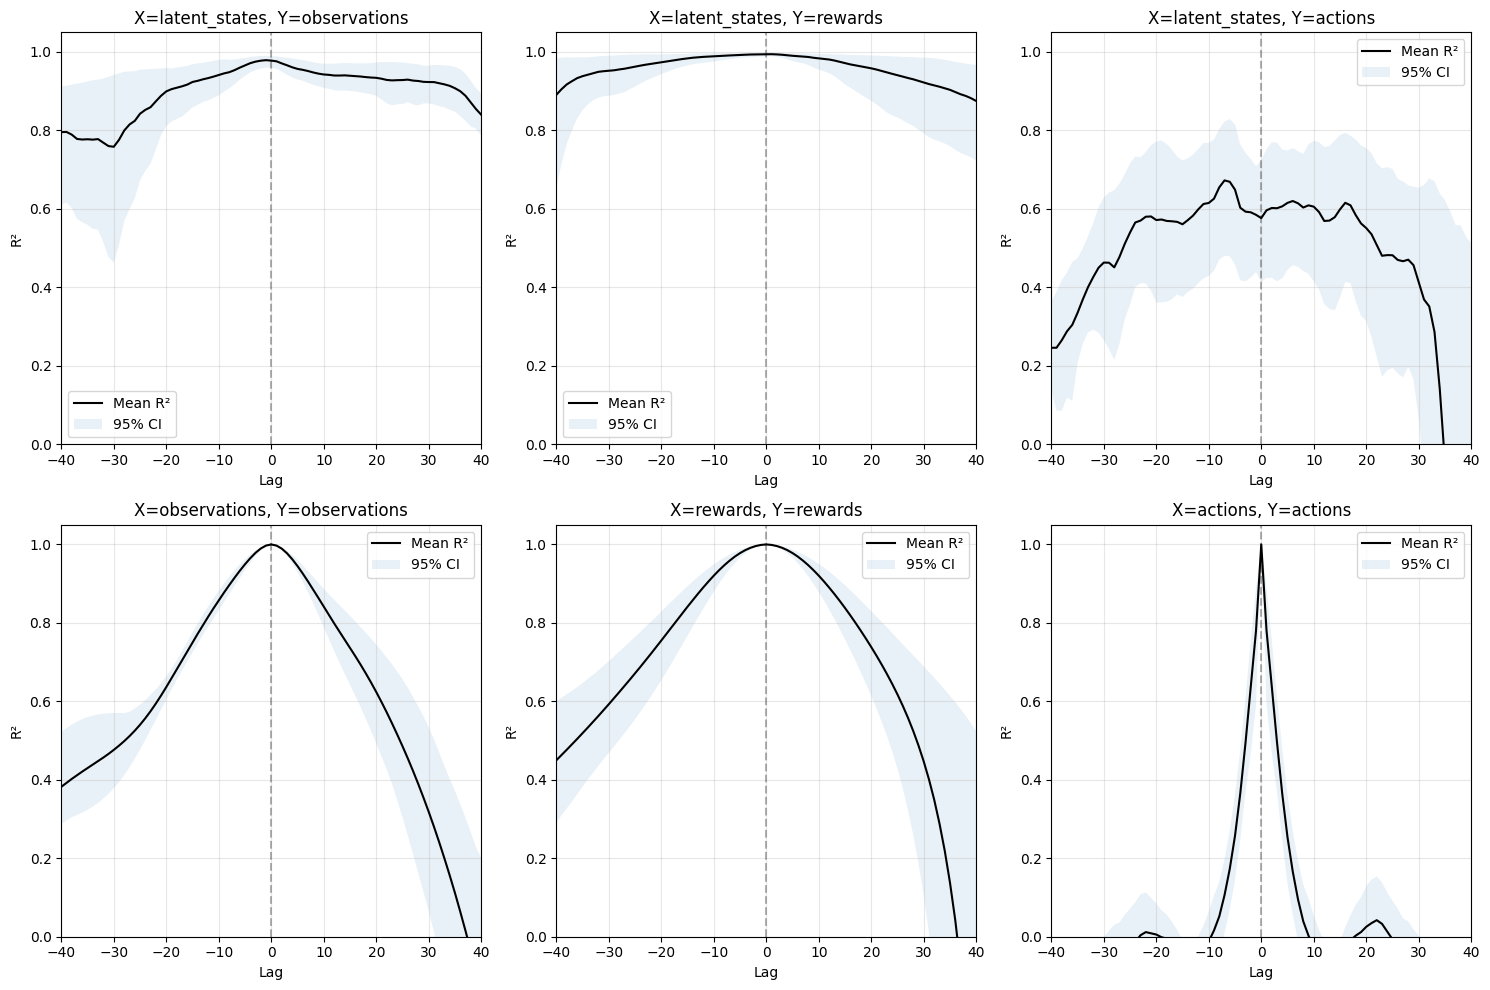

In [ ]:
# Plot R2 means with bootstrapped confidence intervals for each combination
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (key, results) in enumerate(results_decoding_lasso.items()):
    ax = axes[idx]

    r2_mean = results['r2_mean']
    r2_ci = results['r2_ci']

    # Extract lags and R² values from the dictionary
    lags = list(r2_mean.keys())
    means = list(r2_mean.values())

    # r2_ci is a tuple of (lower_dict, upper_dict)
    ci_lower = [r2_ci[lag][0] for lag in lags]
    ci_upper = [r2_ci[lag][1] for lag in lags]

    ax.plot(lags, means, label='Mean R²', color='black')
    ax.fill_between(lags, ci_lower, ci_upper, alpha=0.1, label='95% CI')
    ax.set_xlabel('Lag')
    ax.set_ylabel('R²')
    title = key.split('-')
    ax.set_title(f'X={title[0]}, Y={title[1]}')
    ax.grid(True, alpha=0.3)
    #ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-40, 40)

plt.tight_layout()
plt.show()


## per latent LR

In [ ]:
import numpy as np
from itertools import combinations
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import seaborn as sns
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
def get_model(model):
    if model == 'linear_regression':
        return LinearRegression()
    elif model == 'lasso':
        return Lasso(alpha=0.001)
    elif model == 'ridge':
        return Ridge(alpha=1.0)
    else:
        raise ValueError(f"Model {model} not supported")


def latent_semantics_leave_k_out(
    z_eps,
    y_eps,
    k_holdout=1,
    model='linear_regression',
    mode="joint",  # 'joint' or 'pairwise'
    r2_joint_mode='individual',  # 'individual' or 'global'
    max_combinations=None,
    add_bootstrap_ci=True,
    n_boot=1000,  # number of bootstrap resamples
    ci=95,  # confidence level (percent)
    random_state=0,
):
    """
    Leave-k-episodes-out CV for per-latent semantic regressions, with bootstrap CIs.

    Two modes:
        - 'joint':   y (D-dim) = W_i * z_i + b_i   (one multi-output model per latent)
        - 'pairwise': y_j = w_ij * z_i + b_ij      (one scalar model per latent–output pair)
    """
    assert mode in ("joint", "pairwise"), "mode must be 'joint' or 'pairwise'"

    n_eps = len(z_eps)
    assert n_eps > k_holdout, "k_holdout must be smaller than number of episodes"

    rng = np.random.default_rng(random_state)
    all_combos = list(combinations(range(n_eps), k_holdout))
    if max_combinations is not None and len(all_combos) > max_combinations:
        idxs = rng.choice(len(all_combos), size=max_combinations, replace=False)
        all_combos = [all_combos[i] for i in idxs]

    L = z_eps[0].shape[1]  # number of x dimensions (e.g. latent dims)
    D = y_eps[0].shape[1]  # number of y dimensions (e.g. observation dims)

    # special handling for global R² (single scalar)
    if mode == 'joint' and r2_joint_mode == 'global':
        D_out = 1
    else:
        D_out = D

    r2_by_fold = {}
    #r2_by_fold_train = {}
    fold_idx = 0

    for test_idxs in tqdm(all_combos, desc=f"Leave-{k_holdout}-out ({mode})"):
        test_idxs = np.atleast_1d(test_idxs)
        train_idxs = [i for i in range(n_eps) if i not in test_idxs]

        # Concatenate training and test data
        z_train = np.concatenate([z_eps[i] for i in train_idxs], axis=0)
        y_train = np.concatenate([y_eps[i] for i in train_idxs], axis=0)
        z_test = np.concatenate([z_eps[j] for j in test_idxs], axis=0)
        y_test = np.concatenate([y_eps[j] for j in test_idxs], axis=0)

        #fold_r2_train = np.full((L, D_out), np.nan)
        fold_r2 = np.full((L, D_out), np.nan)

        if mode == "joint":
            # one multi-output regression per latent
            for i in range(L):
                xi_tr = z_train[:, i:i + 1]
                xi_te = z_test[:, i:i + 1]
                model_to_fit = get_model(model).fit(xi_tr, y_train)
                y_pred = model_to_fit.predict(xi_te)

                if r2_joint_mode == 'individual':
                    for d in range(D):
                        fold_r2[i, d] = r2_score(y_test[:, d], y_pred[:, d])
                elif r2_joint_mode == 'global':
                    fold_r2[i, 0] = r2_score(y_test,
                                             y_pred,
                                             multioutput='variance_weighted')

        elif mode == "pairwise":
            # one scalar regression per latent-output pair
            for i in range(L):
                xi_tr = z_train[:, i]
                xi_te = z_test[:, i]
                for d in range(D):
                    model_to_fit = get_model(model).fit(xi_tr.reshape(-1, 1),
                                                        y_train[:, d])
                    y_pred = model_to_fit.predict(xi_te.reshape(-1, 1))
                    fold_r2[i, d] = r2_score(y_test[:, d], y_pred)
                    # fold_r2_train[i, d] = r2_score(
                    #     y_train[:, d],
                    #     model_to_fit.predict(xi_tr.reshape(-1, 1)))
        r2_by_fold[fold_idx] = fold_r2
        #r2_by_fold_train[fold_idx] = fold_r2_train
        fold_idx += 1

    # stack folds → (n_folds, L, D_out)
    r2_stack = np.stack(list(r2_by_fold.values()), axis=0)
    r2_mean = np.nanmean(r2_stack, axis=0)
    r2_std = np.nanstd(r2_stack, axis=0, ddof=1)

    results = {
        'r2_mean': r2_mean,
        'r2_std': r2_std,
        'r2_by_fold': r2_by_fold,
    }

    # -----------------------------
    # Bootstrap confidence intervals
    # -----------------------------

    if add_bootstrap_ci:
        print("Computing bootstrap CIs")
        alpha_p = (100 - ci) / 2
        lower = np.full((L, D_out), np.nan)
        upper = np.full((L, D_out), np.nan)

        for i in tqdm(range(L), desc="Bootstrapping CIs"):
            for d in range(D_out):
                vals = r2_stack[:, i, d]
                vals = vals[~np.isnan(vals)]
                if len(vals) == 0:
                    continue
                boot_means = np.zeros(n_boot)
                for b in range(n_boot):
                    sample = rng.choice(vals, size=len(vals), replace=True)
                    boot_means[b] = np.mean(sample)
                lower[i, d] = np.percentile(boot_means, alpha_p)
                upper[i, d] = np.percentile(boot_means, 100 - alpha_p)

        r2_ci = np.stack([lower, upper], axis=-1)  # (L, D_out, 2)
        results['r2_ci'] = r2_ci

    return results

In [38]:
# z_eps, y_eps = list of arrays per episode

x_var = 'latent_states'
y_var = 'observations'
results = latent_semantics_leave_k_out(exp_vars[x_var],
                                       exp_vars[y_var],
                                       k_holdout=1,
                                       model='linear_regression',
                                       mode='pairwise')

Leave-1-out (pairwise):   0%|          | 0/9 [00:00<?, ?it/s]

Leave-1-out (pairwise): 100%|██████████| 9/9 [00:21<00:00,  2.41s/it]


Computing bootstrap CIs


Bootstrapping CIs: 100%|██████████| 512/512 [00:38<00:00, 13.18it/s]


In [39]:
r2_mean = results['r2_mean']
r2_std = results['r2_std']
r2_ci = results['r2_ci']
r2_by_fold = results['r2_by_fold']

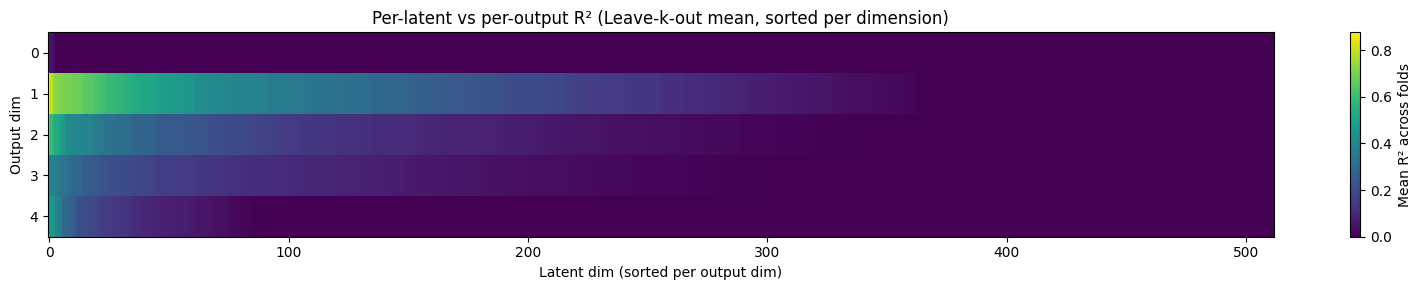

In [42]:
# Sort latent dimensions by their overall magnitude per output dimension

r2_mean = np.maximum(r2_mean, 0)

# Sort each output dimension independently by the magnitude of latent contributions
sorted_r2_mean = np.zeros_like(r2_mean)
for d in range(r2_mean.shape[1]):
    sorted_indices_d = np.argsort(r2_mean[:, d])[::-1]
    sorted_r2_mean[:, d] = r2_mean[sorted_indices_d, d]

plt.figure(figsize=(16, 3))
plt.imshow(sorted_r2_mean.T,
           cmap='viridis',
           interpolation='none',
           aspect='auto',
           vmin=0,
           vmax=r2_mean.max())

plt.colorbar(label='Mean R² across folds')
plt.xlabel('Latent dim (sorted per output dim)')
plt.ylabel('Output dim')
plt.title(
    'Per-latent vs per-output R² (Leave-k-out mean, sorted per dimension)')
plt.tight_layout()
plt.show()

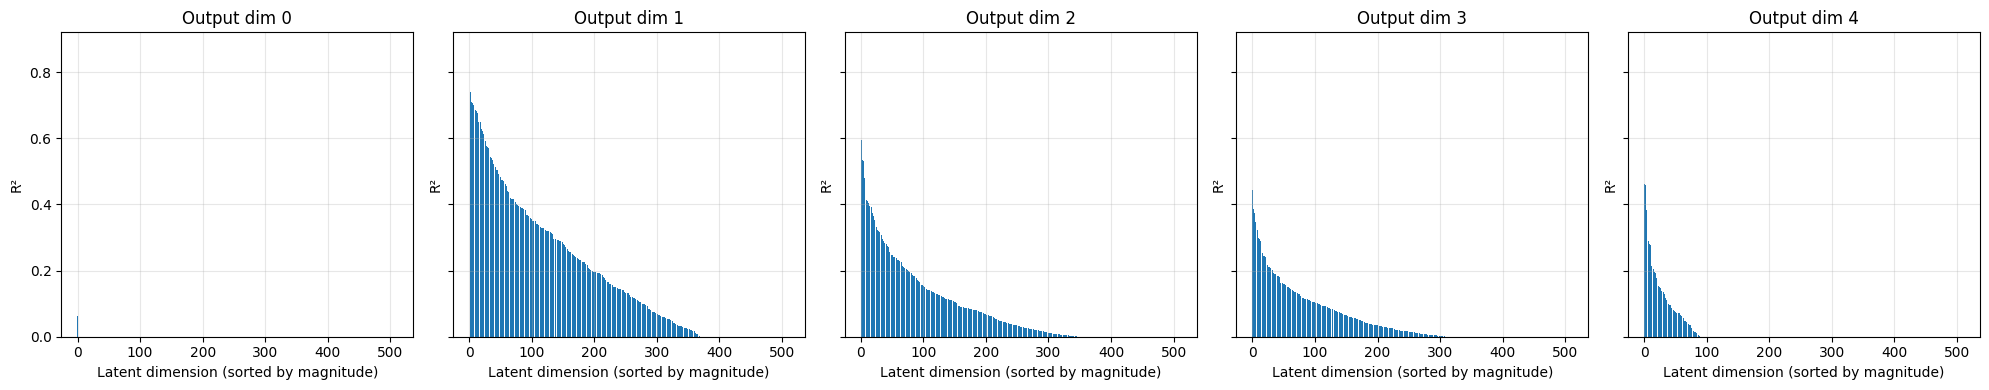

In [43]:
# Create a barplot for each output dimension showing R² vs latent dimension
n_output_dims = r2_mean.shape[1]
n_latent_dims = r2_mean.shape[0]

# Option to sort bars by magnitude
sort_by_magnitude = True

fig, axes = plt.subplots(1,
                         n_output_dims,
                         figsize=(4 * n_output_dims, 4),
                         sharey=True)
if n_output_dims == 1:
    axes = [axes]

for d in range(n_output_dims):
    if sort_by_magnitude:
        # Sort by magnitude (descending)
        sorted_indices = np.argsort(r2_mean[:, d])[::-1]
        sorted_values = r2_mean[sorted_indices, d]
        axes[d].bar(np.arange(n_latent_dims), sorted_values)
        axes[d].set_xlabel('Latent dimension (sorted by magnitude)')
    else:
        axes[d].bar(np.arange(n_latent_dims), r2_mean[:, d])
        axes[d].set_xlabel('Latent dimension')

    axes[d].set_ylabel('R²')
    axes[d].set_title(f'Output dim {d}')
    axes[d].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


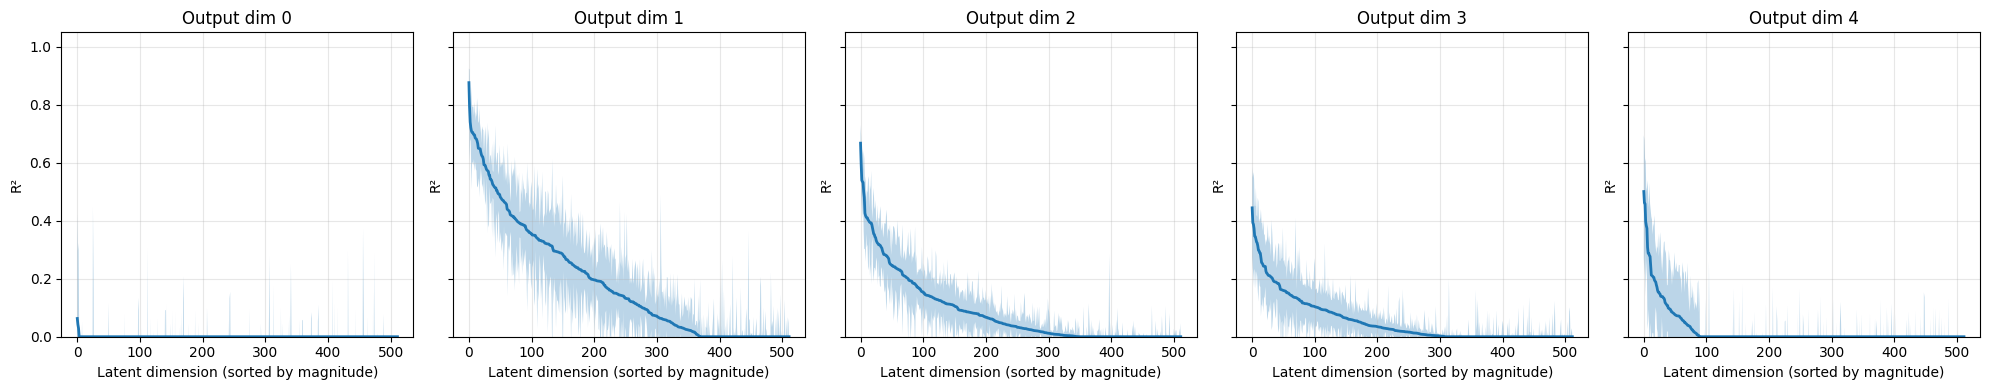

In [48]:
# Create a line plot for each output dimension showing R² vs latent dimension with confidence intervals
n_output_dims = r2_mean.shape[1]
n_latent_dims = r2_mean.shape[0]

# Option to sort by magnitude
sort_by_magnitude = True

fig, axes = plt.subplots(1,
                         n_output_dims,
                         figsize=(4 * n_output_dims, 4),
                         sharey=True)
if n_output_dims == 1:
    axes = [axes]

for d in range(n_output_dims):
    if sort_by_magnitude:
        # Sort by magnitude (descending)
        sorted_indices = np.argsort(r2_mean[:, d])[::-1]
        sorted_values = r2_mean[sorted_indices, d]
        sorted_lower = r2_ci[sorted_indices, d, 0]
        sorted_upper = r2_ci[sorted_indices, d, 1]

        x = np.arange(n_latent_dims)
        axes[d].plot(x, sorted_values, linewidth=2)
        axes[d].fill_between(x, sorted_lower, sorted_upper, alpha=0.3)
        axes[d].set_xlabel('Latent dimension (sorted by magnitude)')
    else:
        x = np.arange(n_latent_dims)
        axes[d].plot(x, r2_mean[:, d], linewidth=2)
        axes[d].fill_between(x, r2_ci[:, d, 0], r2_ci[:, d, 1], alpha=0.3)
        axes[d].set_xlabel('Latent dimension')

    axes[d].set_ylabel('R²')
    axes[d].set_title(f'Output dim {d}')
    axes[d].grid(True, alpha=0.3)
    axes[d].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [70]:
def compute_overlap_matrix(active_latents_dict, metric='jaccard'):
    keys = list(active_latents_dict.keys())
    n = len(keys)
    mat = np.zeros((n, n))
    for i, j in itertools.combinations(range(n), 2):
        A, B = set(active_latents_dict[keys[i]]), set(
            active_latents_dict[keys[j]])
        inter = len(A & B)
        if metric == 'jaccard':
            val = inter / len(A | B) if (A | B) else np.nan
        elif metric == 'overlap':
            val = inter / min(len(A), len(B)) if min(len(A),
                                                     len(B)) > 0 else np.nan
        else:
            raise ValueError("metric must be 'jaccard' or 'overlap'")
        mat[i, j] = mat[j, i] = val
    np.fill_diagonal(mat, 1.0)
    return pd.DataFrame(mat, index=keys, columns=keys)


def get_active_latents(r2_mean,
                       mode='threshold',
                       threshold=0.0,
                       k=10,
                       percentile=90):
    active_latents = {}
    if mode == 'threshold':
        for d in range(n_output_dims):
            active_latents[d] = np.nonzero(r2_mean[:, d] > threshold)[0]
    elif mode == 'topk':
        for d in range(n_output_dims):
            # Get indices of top k latents by R² value
            top_k_indices = np.argsort(r2_mean[:, d])[-k:]
            # Filter to only those with positive R²
            active_latents[d] = top_k_indices[r2_mean[top_k_indices, d] > 0]
    elif mode == 'percentile':
        for d in range(n_output_dims):
            # Compute percentile threshold for this dimension
            pct_threshold = np.percentile(r2_mean[:, d], percentile)
            active_latents[d] = np.nonzero(r2_mean[:, d] > pct_threshold)[0]
    else:
        raise ValueError("mode must be 'threshold', 'topk', or 'percentile'")
    return active_latents


# active_latents = get_active_latents(r2_mean, mode='percentile', percentile=70)
# overlap_df = compute_overlap_matrix(active_latents, metric='overlap')

# sns.heatmap(overlap_df, annot=True, cmap='magma')
# plt.show()

In [75]:
import numpy as np

Ks = np.arange(1, 201)


def mean_overlap_from_matrix(overlap_df):
    mat = overlap_df.values if hasattr(overlap_df,
                                       "values") else np.array(overlap_df)
    n = mat.shape[0]
    tri_upper = mat[np.triu_indices(n, k=1)]  # off-diagonal upper triangle
    return np.nanmean(tri_upper)


overlap_mats = {}
for k in Ks:
    active_latents = get_active_latents(r2_mean, mode='topk', k=k)

    overlap_df = compute_overlap_matrix(active_latents, metric='overlap')
    overlap_mats[k] = overlap_df

mean_overlaps = []
for mat in overlap_mats.values():
    mean_overlaps.append(mean_overlap_from_matrix(mat))

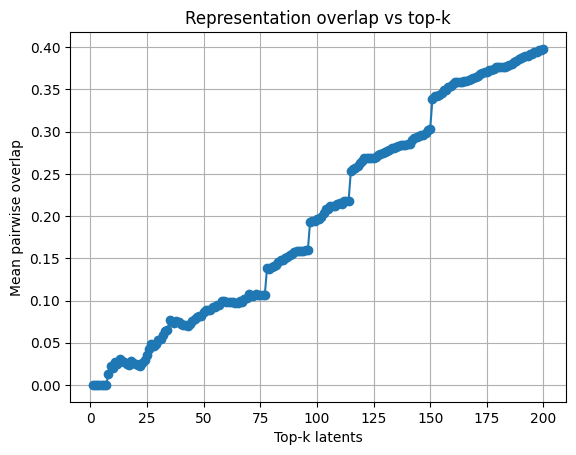

In [ ]:
plt.plot(Ks, mean_overlaps, marker='o')
plt.xlabel('Top-k latents')
plt.ylabel('Mean pairwise overlap')
plt.title('Representation overlap vs top-k')
plt.grid(True)

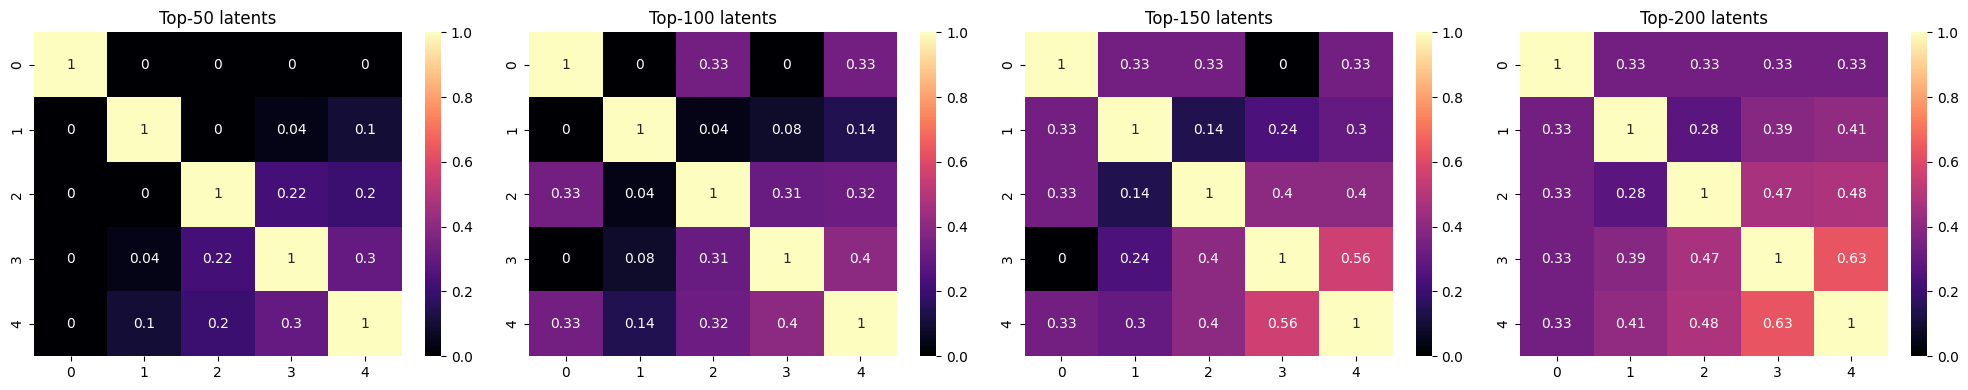

In [77]:
# Plot heatmaps for every 50th k value
selected_ks = [k for k in Ks if k % 50 == 0]
n_plots = len(selected_ks)

fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
if n_plots == 1:
    axes = [axes]

for idx, k in enumerate(selected_ks):
    sns.heatmap(overlap_mats[k],
                annot=True,
                cmap='magma',
                ax=axes[idx],
                vmin=0,
                vmax=1,
                cbar=True)
    axes[idx].set_title(f'Top-{k} latents')

plt.tight_layout()
plt.show()


## LASSO COEFFICIENTS

In [128]:
lasso_models = results_decoding['latent_states-observations']['model_by_lag'][0]

In [129]:
W_list = [m.coef_.T for m in lasso_models]  # list of (L, D) arrays
W_stack = np.stack(W_list, axis=0)  # shape (K, L, D)
K, L, D = W_stack.shape

In [130]:
mean_W = W_stack.mean(axis=0)  # (L, D)
std_W = W_stack.std(axis=0)  # (L, D)

# optional: selection frequency (how often nonzero)
freq_W = (np.abs(W_stack) > 1e-6).mean(axis=0)  # fraction of folds where la

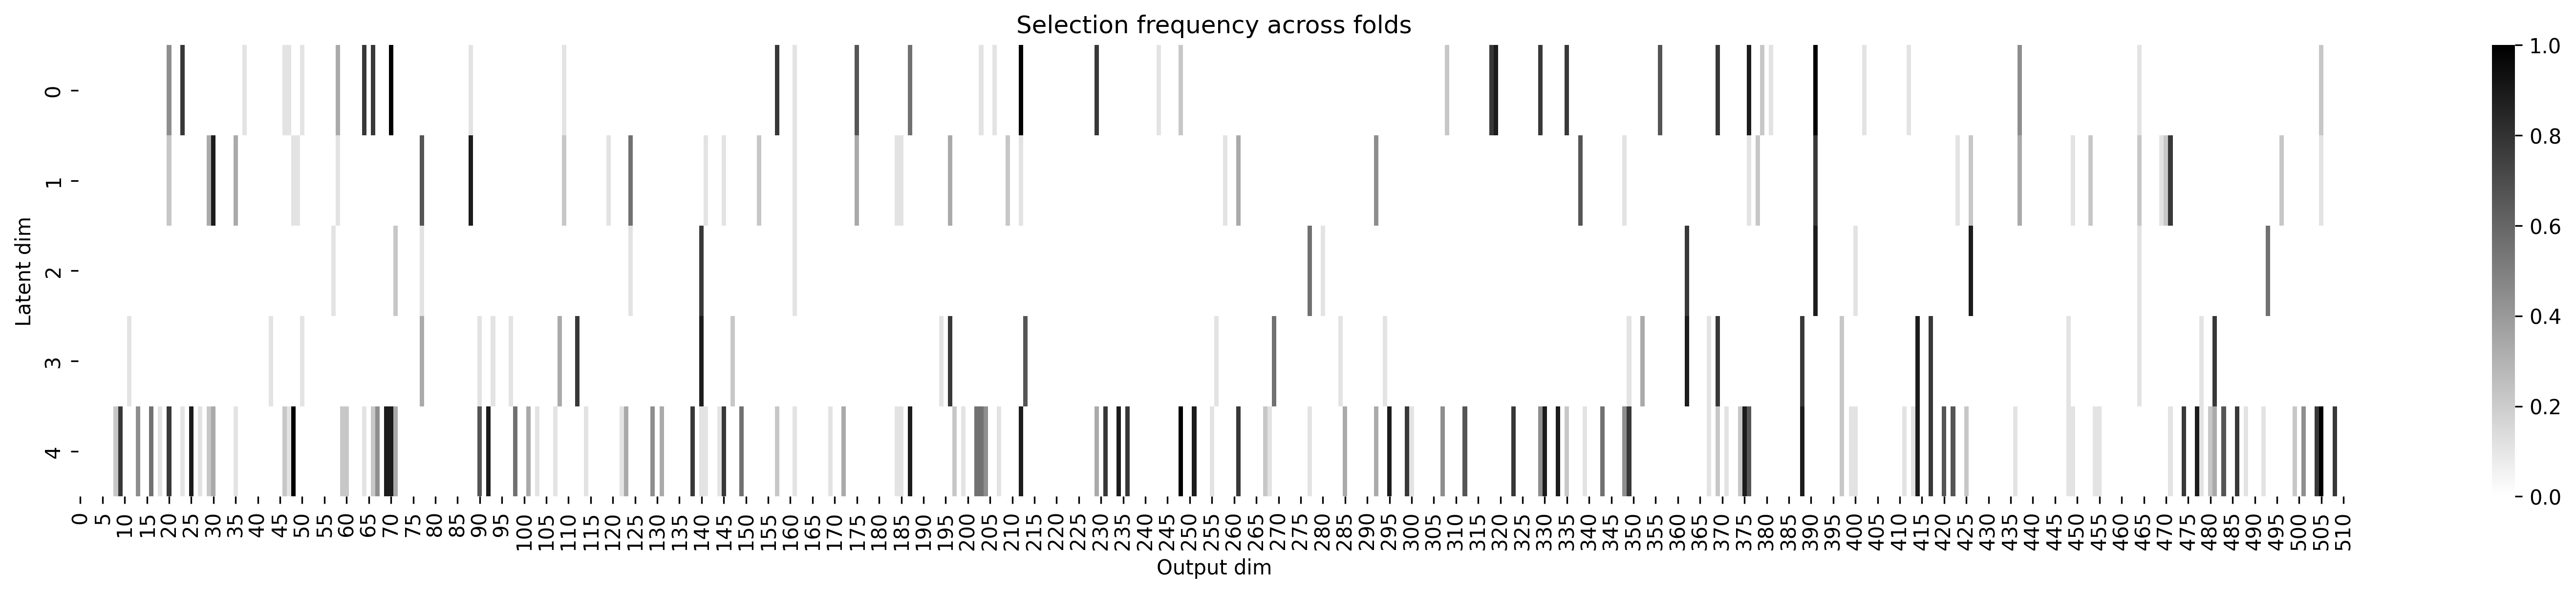

In [131]:
plt.figure(figsize=(25, 4), dpi=300)
sns.heatmap(freq_W.T, cmap='gray_r', annot=False)
plt.xlabel('Output dim')
plt.ylabel('Latent dim')
plt.title('Selection frequency across folds')
plt.show()


In [135]:
W_list[0].T.min()

-3.836254

<Axes: >

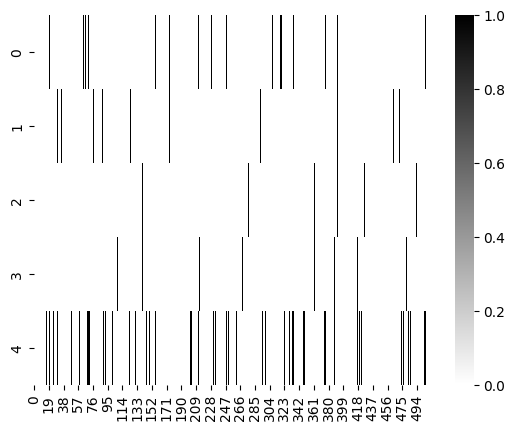

In [136]:
sns.heatmap((np.abs(W_list[0].T) > 1e-6).astype(float),
            cmap='gray_r',
            annot=False)

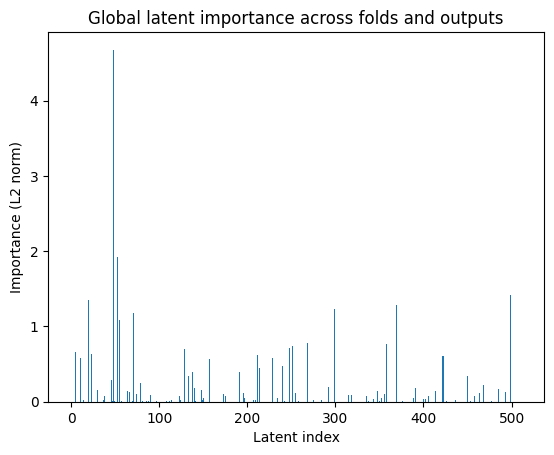

In [120]:
global_importance = np.sqrt((mean_W**2).sum(axis=1))
plt.bar(np.arange(L), global_importance)
plt.title("Global latent importance across folds and outputs")
plt.xlabel("Latent index")
plt.ylabel("Importance (L2 norm)")
plt.show()

Mean within-fold overlap = 0.081


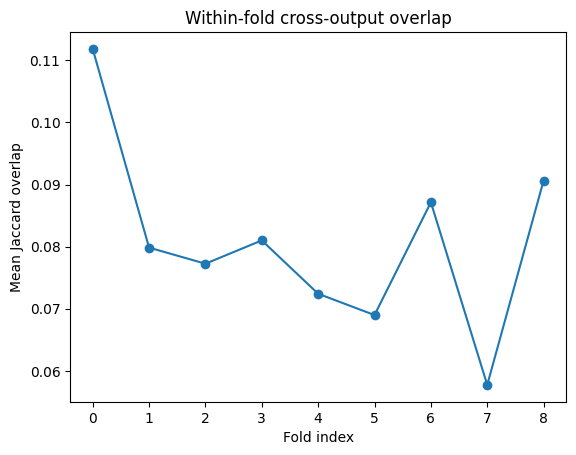

In [121]:
from itertools import combinations


def overlap_within_fold(W, threshold=1e-6):
    L, D = W.shape
    overlaps = []
    for i, j in combinations(range(D), 2):
        A = set(np.where(np.abs(W[:, i]) > threshold)[0])
        B = set(np.where(np.abs(W[:, j]) > threshold)[0])
        if len(A | B) > 0:
            overlaps.append(len(A & B) / len(A | B))
    return np.mean(overlaps) if overlaps else np.nan


overlap_per_fold = [overlap_within_fold(W_stack[k]) for k in range(K)]
print(f"Mean within-fold overlap = {np.mean(overlap_per_fold):.3f}")
plt.plot(overlap_per_fold, marker='o')
plt.title("Within-fold cross-output overlap")
plt.xlabel("Fold index")
plt.ylabel("Mean Jaccard overlap")
plt.show()


Mean sparsity fraction = 0.037


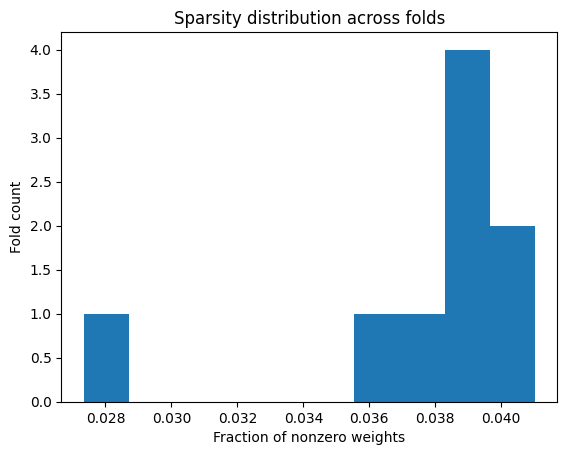

In [122]:
nonzeros_per_fold = (np.abs(W_stack) > 1e-6).sum(axis=(1, 2)) / (L * D)
print(f"Mean sparsity fraction = {np.mean(nonzeros_per_fold):.3f}")
plt.hist(nonzeros_per_fold)
plt.xlabel("Fraction of nonzero weights")
plt.ylabel("Fold count")
plt.title("Sparsity distribution across folds")
plt.show()

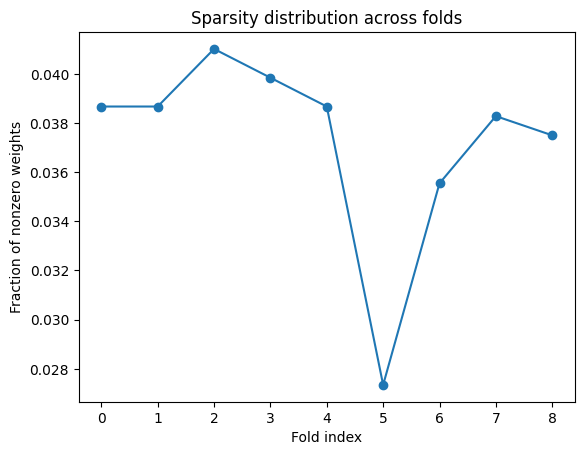

In [138]:
plt.plot(nonzeros_per_fold, marker='o')
plt.title("Sparsity distribution across folds")
plt.xlabel("Fold index")
plt.ylabel("Fraction of nonzero weights")
plt.show()
